In [1]:
import os, shutil
print("Before:", shutil.which("dot"))

# Make dot visible to this kernel session
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ["PATH"]
os.environ["GRAPHVIZ_DOT"] = "/opt/homebrew/bin/dot"

print("After :", shutil.which("dot"))

Before: /opt/homebrew/bin/dot
After : /opt/homebrew/bin/dot


In [ ]:
import sys
import os
sys.path.append('../src')

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from matplotlib import pyplot as plt
import seaborn as sns
from structure_learning.distributions import Distribution, OPAD
from structure_learning.data_structures import DAG
from structure_learning.scores import BGeScore, BDeuScore
from structure_learning.evaluation.metrics import KLD, JSD, MAE, MSE, SHD, MEP

from structure_learning.data import SyntheticDataset, Data
from structure_learning.experiments import Experiment
from structure_learning.evaluation.metrics import RHat
from structure_learning.approximators import StructureMCMC, PartitionMCMC
from structure_learning.inference import CausalEffects
# from structure_learning.inference.causal_effects import normalise_data
# from structure_learning.inference.causal_effects import simulate_do_effects

from scipy.stats import norm


Example 1: DAG with five continuous nodes

In [3]:
# Generate data from a known DAG with continuous variables

np.random.seed(123)

N = 1000

e1 = np.random.normal(0, 1, N)
e2 = np.random.normal(0, 1, N)
e3 = np.random.normal(0, 1, N)
e4 = np.random.normal(0, 1, N)
e5 = np.random.normal(0, 1, N)

X1 = e1
X2 = e2
X3 = 1.5 * X1 + e3
X4 = -1.0 * X2 + e4
X5 = 0.8 * X3 + 1.2 * X4 + e5

data = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "X3": X3,
    "X4": X4,
    "X5": X5
})

domains = {
    "X1": "continuous",
    "X2": "continuous",
    "X3": "continuous",
    "X4": "continuous",
    "X5": "continuous"
}

adj = DAG(
    np.array([
        [0,0,1,0,0], 
        [0,0,0,1,0],  
        [0,0,0,0,1], 
        [0,0,0,0,1],
        [0,0,0,0,0],
    ]),
    data.columns
)

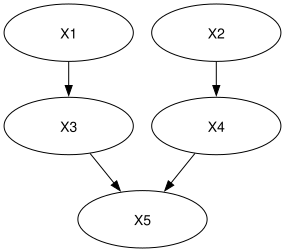

In [4]:
# Visualize the true DAG
adj.plot()

In [12]:
# Run structure MCMC to learn the DAG from data
M1 = StructureMCMC(data=Data(values=data).standardise(ddof=0), score_object='bge', max_iter=4000000, result_type='opad', pc_init= False, graph_type='dag',seed=1000)
results1, acceptance1 = M1.run()
print('Acceptance_ratio:', acceptance1)

MCMC iterations: 4000001iter [08:17, 8035.13iter/s]                           

Acceptance_ratio: 0.1293145


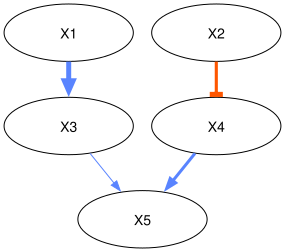

In [13]:
# Visualize the estimated MAP DAG

data_std = (data - data.mean()) / data.std(ddof=1)
node_labels = data_std.columns.tolist()

map_key1 = results1.top(n=1,prop="p").item()
map_dag1 = DAG.from_key(key=map_key1, nodes=node_labels)

w,c = map_dag1.fit(data_std)
map_dag1.plot(edge_colors=c, edge_weights=w)

Single node Intervention

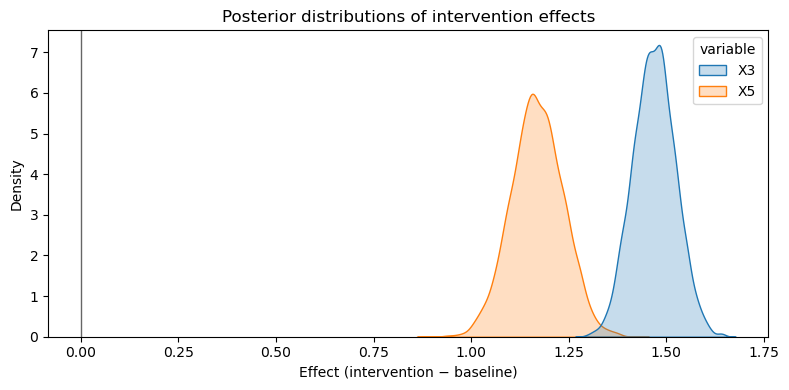

In [14]:
# Simulate intervention do(X1 + 1) and calculate causal effects on all other nodes
# Plot the distribution of intervention effects for each target

ce = CausalEffects(graphs= map_dag1, data=Data(values=data, variable_types=domains))
effects, w = ce.simulate(
    do_map={"X1": 1.0},
    plot=True,
    targets=["X3","X5"],
    kind="kde"
)



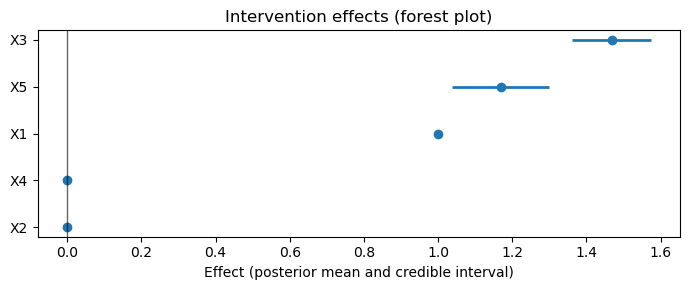

In [15]:
# Plot the mean and credible intervals of intervention effects for all node.
effects, w = ce.simulate(
    do_map={"X1": 1.0},
    plot=True,
    targets=["X1","X2","X3", "X4","X5"],
    kind="forest"
)

In [16]:
# Calculate the mean and standard deviation of the estimated joint intervention effects
mean_effect = effects.mean(axis=0)
sd_effect = effects.std(axis=0)
lower_effect = np.quantile(effects, 0.025, axis=0)
upper_effect = np.quantile(effects, 0.975, axis=0)

In [17]:
# Calculate the true joint post-intervention mean effect for do(X1 + 1.0)
# True coefficient matrix
B = np.array([
    [0.0, 0.0,  1.5, 0.0, 0.0],
    [0.0, 0.0,  0.0, -1.0, 0.0],
    [0.0, 0.0,  0.0, 0.0, 0.8],
    [0.0, 0.0,  0.0, 0.0, 1.2],
    [0.0, 0.0,  0.0, 0.0, 0.0]
])

I = np.eye(B.shape[0])
total_effects = np.linalg.inv(I - B) - I
truth_x1 = total_effects[0]
truth_x1[0] = 1.0  

In [18]:
# Create a results table comparing the estimated effects with the true effects
results = pd.DataFrame({
    "Variable": [f"X{i}" for i in range(1, 6)],
    "Estimated": mean_effect,
    "SD": sd_effect,
    "Truth": truth_x1,
    "Abs_Error": np.abs(mean_effect - truth_x1),
    "CI_Lower": lower_effect,
    "CI_Upper": upper_effect
})

results[["Estimated", "SD", "Truth", "Abs_Error", "CI_Lower", "CI_Upper"]] = results[
    ["Estimated", "SD", "Truth", "Abs_Error", "CI_Lower", "CI_Upper"]
].round(3)

print("\nResults table:")
print(results)


Results table:
  Variable  Estimated     SD  Truth  Abs_Error  CI_Lower  CI_Upper
0       X1      1.000  0.000    1.0      0.000     1.000     1.000
1       X2      0.000  0.000    0.0      0.000     0.000     0.000
2       X3      1.468  0.054    1.5      0.032     1.362     1.574
3       X4      0.000  0.000    0.0      0.000     0.000     0.000
4       X5      1.169  0.067    1.2      0.031     1.037     1.299


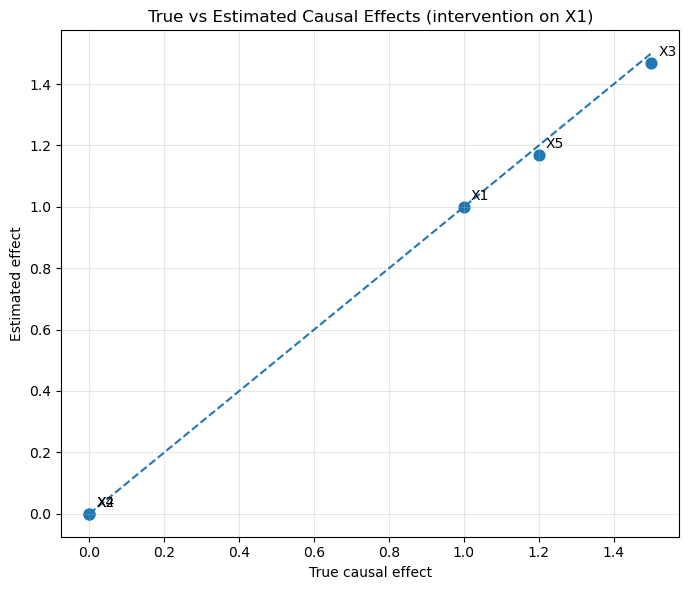

In [19]:
# Plot tru vs estimated causal effects
plt.figure(figsize=(7, 6))

plt.scatter(truth_x1, mean_effect, s=60)

# variable names
var_names = list(data.columns)

# annotate points
for x, y, label in zip(truth_x1, mean_effect, var_names):
    plt.annotate(label, (x, y), xytext=(5, 5), textcoords="offset points")

# 45-degree line
xy_min = min(np.min(truth_x1), np.min(mean_effect))
xy_max = max(np.max(truth_x1), np.max(mean_effect))
plt.plot([xy_min, xy_max], [xy_min, xy_max], linestyle='--')

plt.xlabel("True causal effect")
plt.ylabel("Estimated effect")
plt.title(f"True vs Estimated Causal Effects (intervention on X1)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Joint intervention

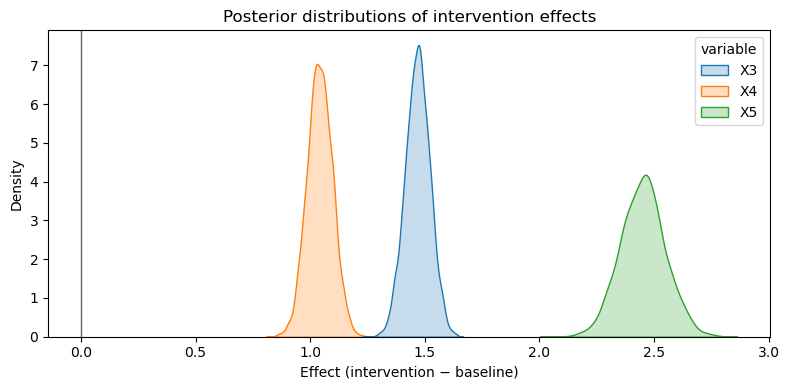

In [20]:
# Simulate intervention do(X1 + 1) and do(X2 - 1) and calculate causal effects on all other nodes
# Plot the distribution of intervention effects for each target

ce_j = CausalEffects(graphs= map_dag1, data=Data(values=data, variable_types=domains))
effects_j, w_j = ce_j.simulate(
    do_map={"X1": 1.0, "X2": -1.0},
    plot=True,
    targets=["X3", "X4","X5"],
    kind="kde"
)


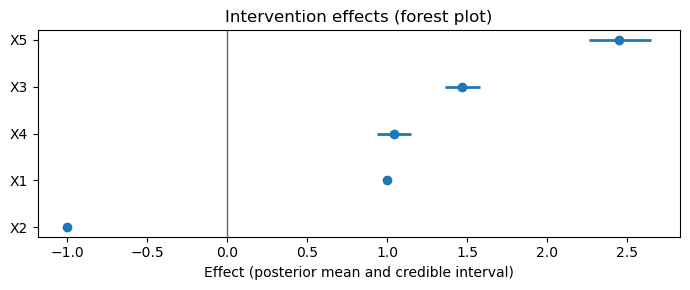

In [21]:
# Plot the mean and credible intervals of intervention effects for all node.
effects_j, w_j = ce_j.simulate(
    do_map={"X1": 1.0, "X2": -1.0},
    plot=True,
    targets=["X1","X2","X3", "X4","X5"],
    kind="forest"
)

In [22]:
# Calculate the true joint post-intervention mean effect for joint intervention on continuous X1 and X2
intervention_idx = [0, 1]        
intervention_values = [1.0, -1.0]

d = np.zeros(B.shape[0])
d[intervention_idx] = intervention_values

B_do = B.copy()
B_do[:, intervention_idx] = 0.0

# True joint post-intervention mean/effect
truth_joint = d @ np.linalg.inv(I - B_do)

In [23]:
# Calculate the mean and standard deviation of the estimated joint intervention effects
mean_effect_j = effects_j.mean(axis=0)
sd_effect_j = effects_j.std(axis=0)
lower_effect_j = np.quantile(effects_j, 0.025, axis=0)
upper_effect_j = np.quantile(effects_j, 0.975, axis=0)

In [24]:
# Create a results table comparing the estimated effects with the true effects
results_j = pd.DataFrame({
    "Variable": [f"X{i}" for i in range(1, 6)],
    "Estimated": mean_effect_j,
    "SD": sd_effect_j,
    "Truth": truth_joint,
    "Abs_Error": np.abs(mean_effect_j - truth_joint),
    "CI_Lower": lower_effect_j,
    "CI_Upper": upper_effect_j
})

results_j[["Estimated", "SD", "Truth", "Abs_Error", "CI_Lower", "CI_Upper"]] = results_j[
    ["Estimated", "SD", "Truth", "Abs_Error", "CI_Lower", "CI_Upper"]
].round(3)

print("\nResults table:")
print(results_j)


Results table:
  Variable  Estimated     SD  Truth  Abs_Error  CI_Lower  CI_Upper
0       X1      1.000  0.000    1.0      0.000     1.000     1.000
1       X2     -1.000  0.000   -1.0      0.000    -1.000    -1.000
2       X3      1.468  0.054    1.5      0.032     1.363     1.576
3       X4      1.041  0.054    1.0      0.041     0.935     1.147
4       X5      2.450  0.098    2.4      0.050     2.261     2.646


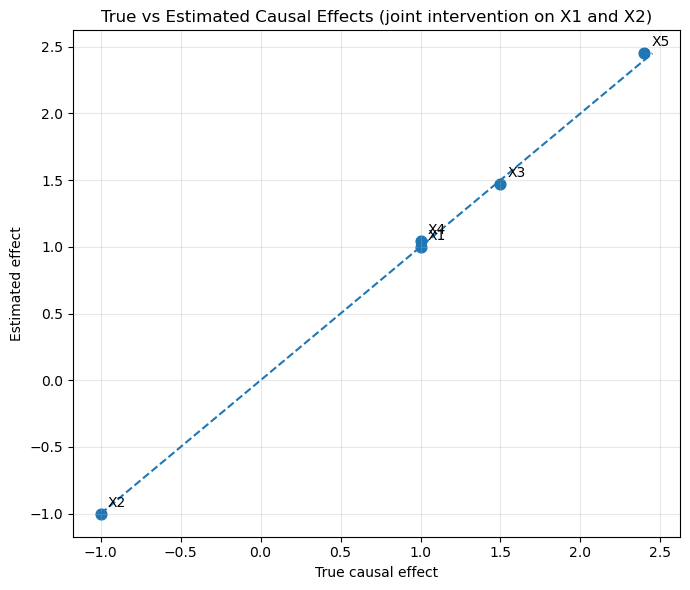

In [25]:
# Plot tru vs estimated causal effects for joint intervention
plt.figure(figsize=(7, 6))

plt.scatter(truth_joint, mean_effect_j, s=60)

# variable names
var_names = list(data.columns)

for x, y, label in zip(truth_joint, mean_effect_j, var_names):
    plt.annotate(label, (x, y), xytext=(5, 5), textcoords="offset points")

xy_min = min(np.min(truth_joint), np.min(mean_effect_j))
xy_max = max(np.max(truth_joint), np.max(mean_effect_j))
plt.plot([xy_min, xy_max], [xy_min, xy_max], linestyle='--')

plt.xlabel("True causal effect")
plt.ylabel("Estimated effect")
plt.title(f"True vs Estimated Causal Effects (joint intervention on X1 and X2)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

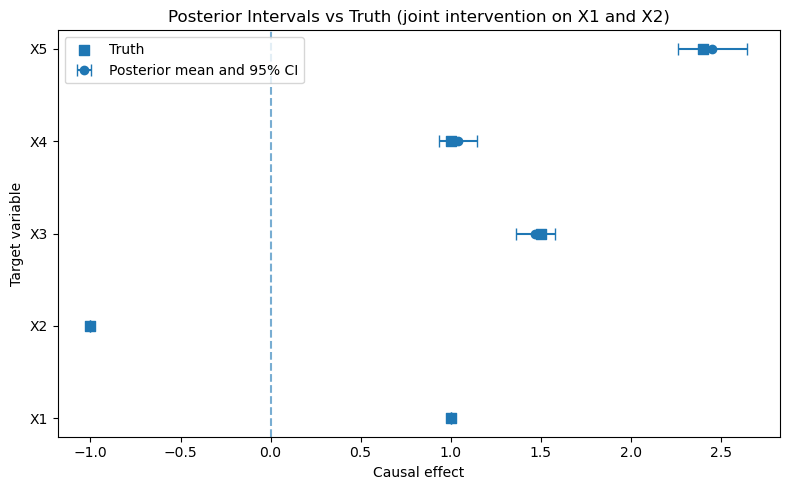

In [26]:

mean_effect_j = np.asarray(mean_effect_j)
lower_effect_j = np.asarray(lower_effect_j)
upper_effect_j = np.asarray(upper_effect_j)
truth_j = np.asarray(truth_joint)
var_names = np.asarray(list(data.columns))

xerr_left = np.maximum(mean_effect_j - lower_effect_j, 0)
xerr_right = np.maximum(upper_effect_j - mean_effect_j, 0)

y_pos = np.arange(len(var_names))

plt.figure(figsize=(8, 5))

plt.errorbar(
    x=mean_effect_j,
    y=y_pos,
    xerr=[xerr_left, xerr_right],
    fmt='o',
    capsize=4,
    label="Posterior mean and 95% CI"
)

plt.scatter(truth_j, y_pos, marker='s', s=60, label="Truth")

plt.yticks(y_pos, var_names)
plt.axvline(0, linestyle='--', alpha=0.6)
plt.xlabel("Causal effect")
plt.ylabel("Target variable")
plt.title(f"Posterior Intervals vs Truth (joint intervention on X1 and X2)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

Example 2: DAG with a mix of continuous and binary variables

In [27]:
# Generate data from a known DAG with a mix of continuous and binary variables
np.random.seed(123)

N = 1000

e1 = np.random.binomial(1, 0.6, size=N)
e2 = np.random.normal(0, 1, N)
e3 = np.random.normal(0, 1, N)
e4 = np.random.normal(0, 1, N)
e5 = np.random.normal(0, 1, N)

X1 = e1
X2 = e2
X3 = 1.5 * X1 + e3
X4 = -1.0 * X2 + e4
X5 = 0.8 * X3 + 1.2 * X4 + e5

data_mixed = pd.DataFrame({
    "X1": X1,
    "X2": X2,
    "X3": X3,
    "X4": X4,
    "X5": X5
})

domains_mixed = {
    "X1": "binary",
    "X2": "continuous",
    "X3": "continuous",
    "X4": "continuous",
    "X5": "continuous"
}

adj_mixed = DAG(
    np.array([
        [0,0,1,0,0], 
        [0,0,0,1,0],  
        [0,0,0,0,1], 
        [0,0,0,0,1],
        [0,0,0,0,0],
    ]),
    data_mixed.columns
)

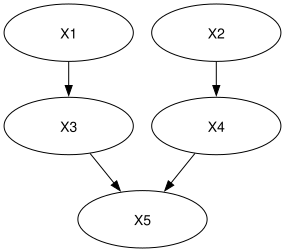

In [28]:
# Visualize the true DAG
adj_mixed.plot()

In [29]:
# Run structure MCMC to learn the DAG from data
np.random.seed(1000)
M2 = StructureMCMC(data=Data(values=data_mixed).standardise(ddof=0), score_object='bge', max_iter=4000000, result_type='opad', pc_init= False, graph_type='dag',seed=1000)
results2, acceptance2 = M2.run()

/Users/165421/Documents/code/structure_learning/src/structure_learning/data/data.py:168: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.25327335  0.79791053  0.79791053  0.79791053 -1.25327335  0.79791053
 -1.25327335 -1.25327335  0.79791053  0.79791053  0.79791053 -1.25327335
  0.79791053  0.79791053  0.79791053 -1.25327335  0.79791053  0.79791053
  0.79791053  0.79791053 -1.25327335 -1.25327335 -1.25327335 -1.25327335
 -1.25327335  0.79791053  0.79791053  0.79791053  0.79791053 -1.25327335
  0.79791053  0.79791053  0.79791053  0.79791053  0.79791053  0.79791053
  0.79791053 -1.25327335 -1.25327335  0.79791053 -1.25327335  0.79791053
  0.79791053  0.79791053 -1.25327335  0.79791053  0.79791053 -1.25327335
  0.79791053 -1.25327335  0.79791053 -1.25327335 -1.25327335  0.79791053
  0.79791053  0.79791053  0.79791053 -1.25327335 -1.25327335  0.79791053
 -1.25327335  0.79791053 -1.25327335 -1.25327335 -1.25327335  0

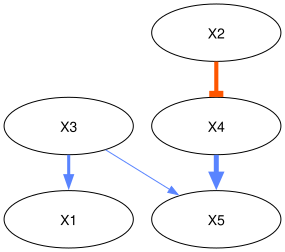

In [31]:
# Visualize the estimated MAP DAG
data_mixed_std = (data_mixed - data_mixed.mean()) / data_mixed.std()
node_labels_mixed = data_mixed_std.columns.tolist()

if not isinstance(data_mixed_std, pd.DataFrame):
    raise ValueError("The 'df' variable must be a pandas DataFrame.")

map_key2 = results2.top(n=5)[0].item()
map_dag2 = DAG.from_key(key=map_key2, nodes=node_labels_mixed)

w,c = map_dag2.fit(data_mixed_std)
map_dag2.plot(edge_colors=c, edge_weights=w)

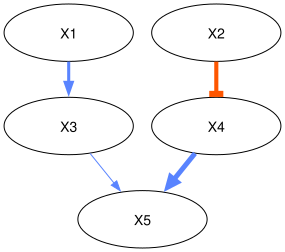

In [32]:
# The fourth best DAG is not the same as the true DAG, thus we will use the fourth best DAG (same as the true DAG) for causal effect estimation
map_key3 = results2.top(n=5)[3].item()
map_dag3 = DAG.from_key(key=map_key3, nodes=node_labels_mixed)
w,c = map_dag3.fit(data_mixed_std)
map_dag3.plot(edge_colors=c, edge_weights=w)

Single binary node intervention

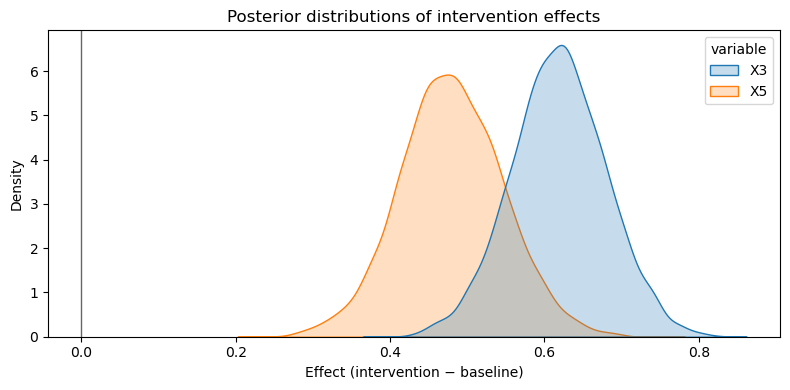

In [33]:
# Calculate estimated causal effects for single intervention on X1
ce_mixed = CausalEffects(graphs=map_dag3, data=Data(values=data_mixed, variable_types=domains_mixed))
effects_mixed, w_mixed = ce_mixed.simulate(
    do_map={"X1": 1.0},
    plot=True,
    targets=[ "X3","X5"],
    kind="kde"
)


In [34]:
# Calculate the mean and standard deviation of the estimated intervention effects
mean_effect_mixed = effects_mixed.mean(axis=0)
sd_effect_mixed = effects_mixed.std(axis=0)
lower_effect_mixed = np.quantile(effects_mixed, 0.025, axis=0)
upper_effect_mixed = np.quantile(effects_mixed, 0.975, axis=0)

In [35]:
# Functions to calculate true causal effects for single intervention on X1 and joint intervention on X1 and X2

# True baseline means under the known DGP
def true_baseline_means_mixed():
    """
    Baseline means under the true SEM:

    X1 ~ Bernoulli(0.6)
    X2 ~ N(0,1)
    X3 = 1.5 * X1 + e3
    X4 = -1.0 * X2 + e4
    X5 = 0.8 * X3 + 1.2 * X4 + e5
    """

    muX1 = 0.6
    muX2 = 0.0
    muX3 = 1.5 * muX1
    muX4 = -1.0 * muX2
    muX5 = 0.8 * muX3 + 1.2 * muX4

    return {
        "X1": muX1,
        "X2": muX2,
        "X3": muX3,
        "X4": muX4,
        "X5": muX5
    }


# True effect for intervening on X1 only
# X1 is binary -> hard set X1 := x1_do
def true_effect_doX1(x1_do):
    if x1_do not in (0, 1):
        raise ValueError("X1 is binary, so x1_do must be 0 or 1.")

    base = true_baseline_means_mixed()

    muX1_do = int(x1_do)
    muX2_do = 0.0
    muX3_do = 1.5 * muX1_do
    muX4_do = -1.0 * muX2_do
    muX5_do = 0.8 * muX3_do + 1.2 * muX4_do

    do_means = {
        "X1": muX1_do,
        "X2": muX2_do,
        "X3": muX3_do,
        "X4": muX4_do,
        "X5": muX5_do
    }

    return {k: do_means[k] - base[k] for k in base}


# True effect for jointly intervening on X1 and X2
# X1 is binary -> hard set X1 := x1_do
# X2 is continuous -> soft shift X2 := X2 + x2_shift
def true_effect_doX1_shiftX2(x1_do, x2_shift):
    if x1_do not in (0, 1):
        raise ValueError("X1 is binary, so x1_do must be 0 or 1.")

    base = true_baseline_means_mixed()

    muX1_do = int(x1_do)
    muX2_do = float(x2_shift)
    muX3_do = 1.5 * muX1_do
    muX4_do = -1.0 * muX2_do
    muX5_do = 0.8 * muX3_do + 1.2 * muX4_do

    do_means = {
        "X1": muX1_do,
        "X2": muX2_do,
        "X3": muX3_do,
        "X4": muX4_do,
        "X5": muX5_do
    }

    return {k: do_means[k] - base[k] for k in base}

In [36]:
# Calculate true causal effects for single intervention on X1
truth_X1 = true_effect_doX1(x1_do=1)
var_order = ['X1', 'X2', 'X3', 'X4', 'X5']
truth_X1_series = pd.Series(truth_X1).reindex(var_order)

print(truth_X1_series)

X1    0.40
X2    0.00
X3    0.60
X4    0.00
X5    0.48
dtype: float64


In [37]:
# Create a results table comparing the estimated effects with the true effects
results_mixed = pd.DataFrame({
    "Variable": var_order,
    "Estimated": mean_effect_mixed,
    "SD": sd_effect_mixed,
    "Truth": truth_X1_series.values,
    "Abs_Error": np.abs(mean_effect_mixed - truth_X1_series.values),
    "CI_Lower": lower_effect_mixed,
    "CI_Upper": upper_effect_mixed
})

results_mixed[["Estimated", "SD", "Truth", "Abs_Error", "CI_Lower", "CI_Upper"]] = results_mixed[
    ["Estimated", "SD", "Truth", "Abs_Error", "CI_Lower", "CI_Upper"]
].round(3)

print("\nResults table:")
print(results_mixed)


Results table:
  Variable  Estimated     SD  Truth  Abs_Error  CI_Lower  CI_Upper
0       X1      0.389  0.022   0.40      0.011     0.348     0.431
1       X2      0.000  0.000   0.00      0.000     0.000     0.000
2       X3      0.618  0.061   0.60      0.018     0.497     0.739
3       X4      0.000  0.000   0.00      0.000     0.000     0.000
4       X5      0.479  0.067   0.48      0.001     0.346     0.613


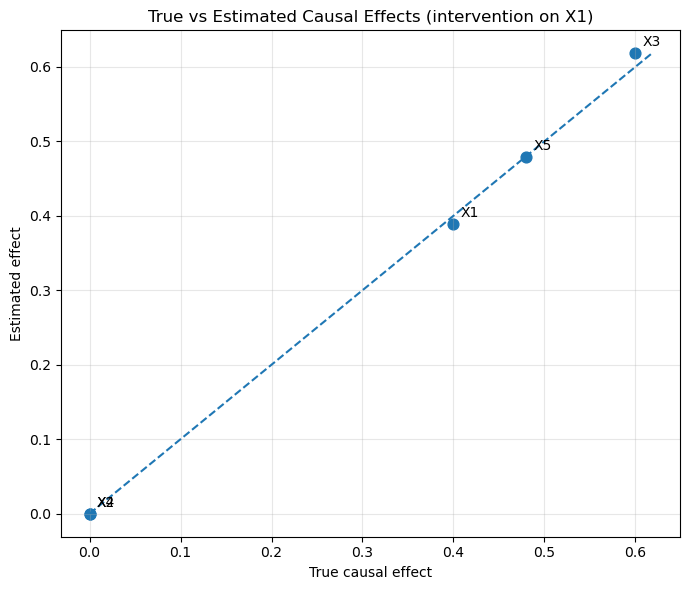

In [38]:
# Plot true vs estimated causal effects for intervention on mixed data

var_order = ['X1', 'X2', 'X3', 'X4', 'X5']
truth_X1_series = pd.Series(truth_X1).reindex(var_order)
plt.figure(figsize=(7, 6))

plt.scatter(truth_X1_series.values, mean_effect_mixed, s=60)

for x, y, label in zip(truth_X1_series.values, mean_effect_mixed, var_order):
    plt.annotate(label, (x, y), xytext=(5, 5), textcoords="offset points")

xy_min = min(np.min(truth_X1_series.values), np.min(mean_effect_mixed))
xy_max = max(np.max(truth_X1_series.values), np.max(mean_effect_mixed))
plt.plot([xy_min, xy_max], [xy_min, xy_max], linestyle='--')

plt.xlabel("True causal effect")
plt.ylabel("Estimated effect")
plt.title("True vs Estimated Causal Effects (intervention on X1)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Joint intervention on mixed data

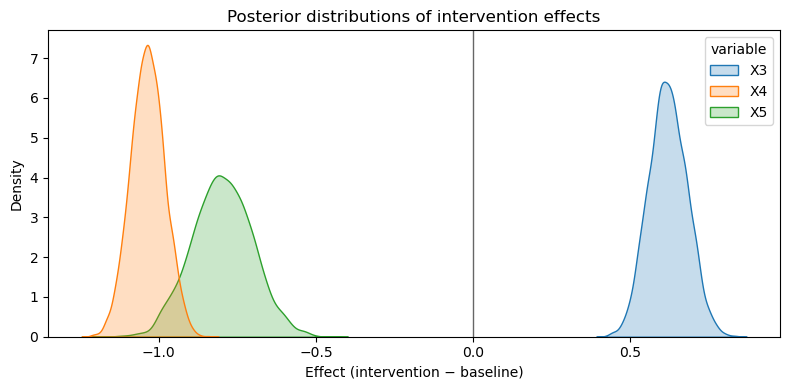

In [39]:
# Calculate estimated causal effects for joint intervention on X1 and X2

effects_mixed_joint, w_mixed_joint = ce_mixed.simulate(
    do_map={"X1": 1.0, "X2": 1.0},
    plot=True,
    targets=["X3", "X4","X5"],
    kind="kde"
)


In [40]:
# Calculate the mean and standard deviation of the estimated intervention effects
mean_effect_mixed_joint = effects_mixed_joint.mean(axis=0)
sd_effect_mixed_joint = effects_mixed_joint.std(axis=0)
lower_effect_mixed_joint = np.quantile(effects_mixed_joint, 0.025, axis=0)
upper_effect_mixed_joint = np.quantile(effects_mixed_joint, 0.975, axis=0)

In [41]:
# Calculate true causal effects for joint intervention on X1 and X2
truth_X1_X2 = true_effect_doX1_shiftX2(x1_do=1, x2_shift=1.0)

var_order = ['X1', 'X2', 'X3', 'X4', 'X5']
truth_X1_X2_series = pd.Series(truth_X1_X2).reindex(var_order)

print(truth_X1_X2_series)

X1    0.40
X2    1.00
X3    0.60
X4   -1.00
X5   -0.72
dtype: float64


In [42]:
# Create a results table comparing the estimated effects with the true effects
results_mixed_joint = pd.DataFrame({
    "Variable": var_order,
    "Estimated": mean_effect_mixed_joint,
    "SD": sd_effect_mixed_joint,
    "Truth": truth_X1_X2_series.values,
    "Abs_Error": np.abs(mean_effect_mixed_joint - truth_X1_X2_series.values),
    "CI_Lower": lower_effect_mixed_joint,
    "CI_Upper": upper_effect_mixed_joint
})

results_mixed_joint[["Estimated", "SD", "Truth", "Abs_Error", "CI_Lower", "CI_Upper"]] = results_mixed_joint[
    ["Estimated", "SD", "Truth", "Abs_Error", "CI_Lower", "CI_Upper"]
].round(3)

print("\nResults table:")
print(results_mixed_joint)


Results table:
  Variable  Estimated     SD  Truth  Abs_Error  CI_Lower  CI_Upper
0       X1      0.390  0.022   0.40      0.010     0.347     0.432
1       X2      1.000  0.000   1.00      0.000     1.000     1.000
2       X3      0.619  0.061   0.60      0.019     0.502     0.739
3       X4     -1.036  0.054  -1.00      0.036    -1.141    -0.931
4       X5     -0.799  0.096  -0.72      0.079    -0.988    -0.608


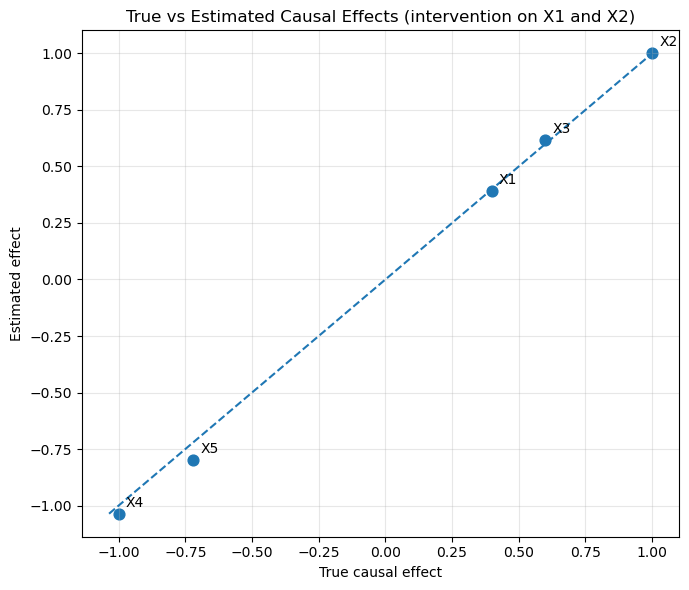

In [43]:
# Plot tru vs estimated causal effectsfor joint intervention on mixed data
var_order = ['X1', 'X2', 'X3', 'X4', 'X5']
truth_X1_X2_series = pd.Series(truth_X1_X2).reindex(var_order)
plt.figure(figsize=(7, 6))

plt.scatter(truth_X1_X2_series.values, mean_effect_mixed_joint, s=60)

for x, y, label in zip(truth_X1_X2_series.values, mean_effect_mixed_joint, var_order):
    plt.annotate(label, (x, y), xytext=(5, 5), textcoords="offset points")

xy_min = min(np.min(truth_X1_X2_series.values), np.min(mean_effect_mixed_joint))
xy_max = max(np.max(truth_X1_X2_series.values), np.max(mean_effect_mixed_joint))
plt.plot([xy_min, xy_max], [xy_min, xy_max], linestyle='--')

plt.xlabel("True causal effect")
plt.ylabel("Estimated effect")
plt.title("True vs Estimated Causal Effects (intervention on X1 and X2)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()